<div align="left">
    <img src="../assets/logo_evaliax.png" width="450"
         alt="EVALIAX logo"/>
</div>

# EVALIAX Tutorial: Causal Forest for Policy Evaluation


This notebook introduces **Causal Forests** for estimating heterogeneous treatment effects (HTE) in policy evaluation.

Causal Forests extend Random Forests to causal inference settings and allow treatment effects to vary across observations ([Wager & Athey, 2018](https://doi.org/10.1080/01621459.2017.1319839)). The method combines machine learning flexibility with asymptotic statistical properties and has become one of the most influential approaches in causal machine learning and policy evaluation. Recent developments integrating orthogonalization and Double Machine Learning further improved robustness to nuisance parameter estimation ([Chernozhukov et al., 2018](https://doi.org/10.1111/ectj.12097); [Athey et al., 2019](https://doi.org/10.1214/18-AOS1709)).

The tutorial is designed for PhD students and applied researchers interested in:

- causal machine learning,
- treatment effect heterogeneity,
- policy targeting,
- and interpretable policy analytics.

We analyze a simulated public subsidy program where firms may receive a digitalization subsidy. The example is inspired by recent applications of causal machine learning in public policy and targeted interventions ([Athey & Imbens, 2019](https://doi.org/10.1146/annurev-economics-080217-053433)).




# 1. Policy evaluation setting

We consider a policy intervention where firms may receive a public subsidy.

The treatment is binary:



$\displaystyle
T_i =
\begin{cases}
1, & \text{if firm } i \text{ receives the subsidy} \\
0, & \text{otherwise}
\end{cases}
$


The objective is to estimate:

$\displaystyle
\tau(X)=\mathbb{E}[Y(1)-Y(0)\mid X]
$

where:

- $Y(1)$: potential outcome with treatment,
- $Y(0)$: potential outcome without treatment,
- $X$: firm characteristics observed before treatment.

Unlike traditional policy evaluation methods that estimate average effects, Causal Forests allow treatment effects to vary across firms.

In [1]:

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from econml.dml import CausalForestDML

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (7,5)



# 2. Load the simulated dataset

The dataset contains:

- firm characteristics,
- sector and regional information,
- treatment assignment,
- post-treatment outcomes,
- and the true treatment effect.

Because the data are simulated, we know the ground-truth treatment effect. This allows us to evaluate how well the model recovers treatment heterogeneity.


In [2]:

# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_csv(
    "../data/simulated_subsidy_dataset.csv"
)

print(df.head())

print("\nDataset shape:")
print(df.shape)


   firm_id  size  age sector_code             sector_description  \
0        1    30   40           C                  Manufacturing   
1        2    18    1           J  Information and communication   
2        3    34    4           C                  Manufacturing   
3        4    68   30           J  Information and communication   
4        5    17   12           H     Transportation and storage   

   productivity  debt_ratio  profitability     region  aid_received  \
0     67.838397    0.357878       0.150633     Murcia             1   
1     60.008677    0.160489       0.068931    Galicia             0   
2     49.576732    0.054043       0.023460   Valencia             1   
3     70.464894    0.053263       0.105453  Andalusia             1   
4     59.938041    0.206822       0.060447     Madrid             1   

   p_treatment  grant_amount  log_grant_amount  true_effect  \
0     0.535370   5138.028620          8.544619     2.300506   
1     0.565620      0.000000          


# 3. Define outcome, treatment and covariates

## Outcome

We focus on:

- value added growth.

## Treatment

The treatment variable is:

- receiving the subsidy.

## Covariates

The covariates must be:

- observed before treatment,
- and not affected by treatment assignment.


In [3]:

# ==========================================================
# 3. DEFINE Y, T AND X
# ==========================================================

# Outcome
Y = df["value_added_growth"]

# Treatment
T = df["aid_received"]

# Covariates
X = df[
    [
        "size",
        "age",
        "sector_code",
        "productivity",
        "debt_ratio",
        "profitability",
        "region"
    ]
]

# Ground-truth effect for value added growth
true_effect = df["true_effect"] * 1.6



# 4. One-hot encoding

Machine learning estimators require numerical inputs.

We therefore transform categorical variables into dummy variables.


In [4]:

# ==========================================================
# 4. ONE-HOT ENCODING
# ==========================================================

X_encoded = pd.get_dummies(
    X,
    columns=["sector_code", "region"],
    drop_first=True
)

print(X_encoded.head())


   size  age  productivity  debt_ratio  profitability  sector_code_F  \
0    30   40     67.838397    0.357878       0.150633          False   
1    18    1     60.008677    0.160489       0.068931          False   
2    34    4     49.576732    0.054043       0.023460          False   
3    68   30     70.464894    0.053263       0.105453          False   
4    17   12     59.938041    0.206822       0.060447          False   

   sector_code_G  sector_code_H  sector_code_I  sector_code_J  ...  \
0          False          False          False          False  ...   
1          False          False          False           True  ...   
2          False          False          False          False  ...   
3          False          False          False           True  ...   
4          False           True          False          False  ...   

   region_Catalonia  region_Ceuta  region_Extremadura  region_Galicia  \
0             False         False               False           False   



# 5. Train-test split

We divide the sample into:

- training observations,
- testing observations.

The test sample allows us to evaluate out-of-sample causal performance.


In [5]:

# ==========================================================
# 5. TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, Y_train, Y_test, T_train, T_test, true_train, true_test = train_test_split(
    X_encoded,
    Y,
    T,
    true_effect,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 3500
Testing observations: 1500


# 6. Nuisance models

Causal Forests rely on auxiliary models known as nuisance models.

These models estimate:

## Outcome model

$\displaystyle
m(X)=\mathbb{E}[Y \mid X]
$

## Treatment model

$\displaystyle
e(X)=P(T=1 \mid X)
$

The causal effect is estimated after orthogonalization and residualization.

In [6]:

# ==========================================================
# 6. NUISANCE MODELS
# ==========================================================

model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)



# 7. Estimate the Causal Forest

The Causal Forest estimates:

$\displaystyle
\tau(X)=E[Y(1)-Y(0)|X]
$

allowing treatment effects to vary across firms.


In [7]:

# ==========================================================
# 7. CAUSAL FOREST
# ==========================================================

causal_forest = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    n_estimators=1000,
    min_samples_leaf=100,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

causal_forest.fit(
    Y_train,
    T_train,
    X=X_train
)



# 8. Estimate heterogeneous treatment effects

We estimate the Conditional Average Treatment Effect (CATE) for firms in the test sample.


In [8]:

# ==========================================================
# 8. ESTIMATED TREATMENT EFFECTS
# ==========================================================

estimated_effect_test = causal_forest.effect(X_test)

print(estimated_effect_test[:10])


[2.4587941  2.49398424 2.77944311 2.36998074 2.80248439 2.47783
 3.55368068 2.49157243 3.28620586 3.47746794]



# 9. Evaluate the model

Because the data are simulated, we can compare:

- estimated treatment effects,
- and true treatment effects.


In [9]:

# ==========================================================
# 9. MODEL EVALUATION
# ==========================================================

rmse = np.sqrt(
    mean_squared_error(
        true_test,
        estimated_effect_test
    )
)

mae = mean_absolute_error(
    true_test,
    estimated_effect_test
)

correlation = np.corrcoef(
    true_test,
    estimated_effect_test
)[0,1]

print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("Correlation:", round(correlation, 3))


RMSE: 0.731
MAE: 0.598
Correlation: 0.702


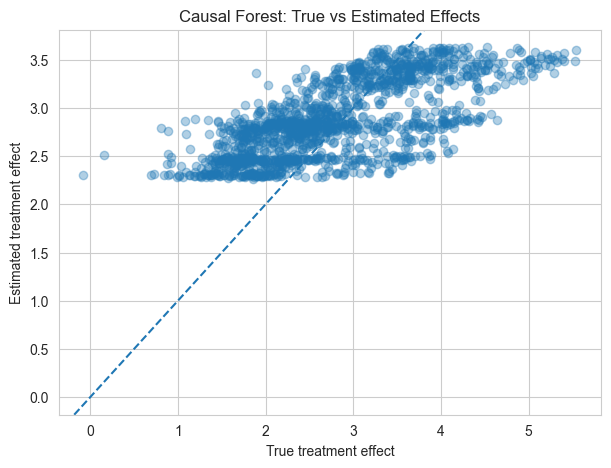

In [10]:

# ==========================================================
# 10. TRUE VS ESTIMATED EFFECTS
# ==========================================================

plt.figure(figsize=(7,5))

plt.scatter(
    true_test,
    estimated_effect_test,
    alpha=0.35
)

plt.axline(
    (0,0),
    slope=1,
    linestyle="--"
)

plt.xlabel("True treatment effect")
plt.ylabel("Estimated treatment effect")

plt.title(
    "Causal Forest: True vs Estimated Effects"
)

plt.show()



# Interpretation

- Points close to the diagonal indicate good recovery of treatment heterogeneity.
- Systematic deviations may indicate:
    - poor overlap,
    - overfitting,
    - or noisy nuisance models.



# 11. Average Treatment Effect (ATE)

Although the main objective is heterogeneous effects, we can also compare:

- estimated ATE,
- and true ATE.


In [11]:

# ==========================================================
# 11. ATE COMPARISON
# ==========================================================

estimated_ate = np.mean(estimated_effect_test)

true_ate = np.mean(true_test)

print("Estimated ATE:", round(estimated_ate, 3))
print("True ATE:", round(true_ate, 3))


Estimated ATE: 2.874
True ATE: 2.781


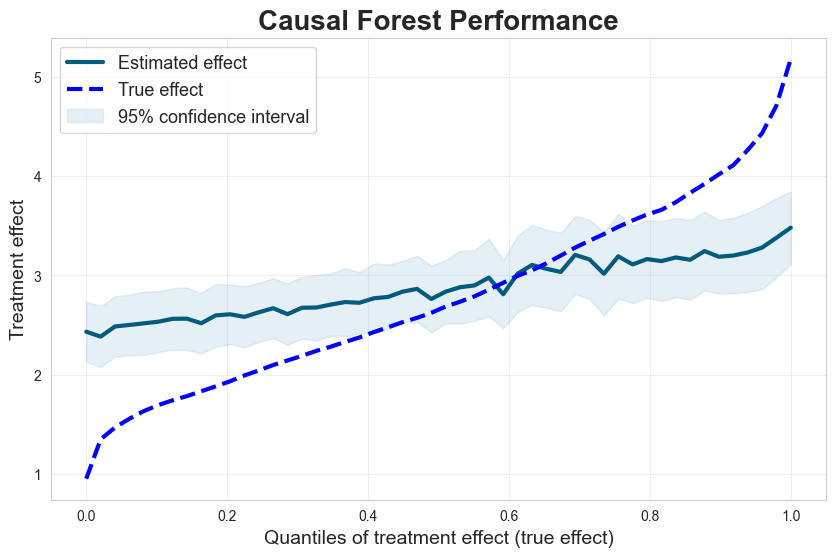

In [12]:
# ==========================================================
# SMOOTH PERFORMANCE PLOT
# ==========================================================

# Confidence intervals
lb, ub = causal_forest.effect_interval(X_test)

# Create dataframe
performance_df = pd.DataFrame({
    "true_effect": true_test,
    "estimated_effect": estimated_effect_test,
    "lower_bound": lb,
    "upper_bound": ub
})

# Sort by true effect
performance_df = performance_df.sort_values(
    "true_effect"
).reset_index(drop=True)

# ----------------------------------------------------------
# Create quantile bins
# ----------------------------------------------------------

n_bins = 50

performance_df["bin"] = pd.qcut(
    performance_df.index,
    q=n_bins,
    labels=False
)

# Aggregate within bins
plot_df = (
    performance_df
    .groupby("bin")
    .agg({
        "true_effect": "mean",
        "estimated_effect": "mean",
        "lower_bound": "mean",
        "upper_bound": "mean"
    })
)

# X axis
x_axis = np.linspace(
    0,
    1,
    len(plot_df)
)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(10,6))

# Estimated effect
plt.plot(
    x_axis,
    plot_df["estimated_effect"],
    linewidth=3,
    color="#005B7F",
    label="Estimated effect"
)

# True effect
plt.plot(
    x_axis,
    plot_df["true_effect"],
    linestyle="--",
    linewidth=3,
    color="blue",
    label="True effect"
)

# Confidence intervals
plt.fill_between(
    x_axis,
    plot_df["lower_bound"],
    plot_df["upper_bound"],
    alpha=0.20,
    color="#7FB3D5",
    label="95% confidence interval"
)

# Labels
plt.xlabel(
    "Quantiles of treatment effect (true effect)",
    fontsize=14
)

plt.ylabel(
    "Treatment effect",
    fontsize=14
)

plt.title(
    "Causal Forest Performance",
    fontsize=20,
    weight="bold"
)

# Legend
plt.legend(
    fontsize=13
)

plt.grid(alpha=0.3)

plt.show()


# 12. Sectoral heterogeneity

One of the main advantages of Causal Forests is the identification of heterogeneous effects across groups.

We first analyze heterogeneity across sectors.


In [14]:

# ==========================================================
# 12. SECTORAL HETEROGENEITY
# ==========================================================

sector_results = pd.DataFrame({
    "sector": X.loc[X_test.index, "sector_code"],
    "estimated_effect": estimated_effect_test
})

sector_summary = (
    sector_results
    .groupby("sector")["estimated_effect"]
    .mean()
    .sort_values(ascending=False)
)

print(sector_summary)


sector
M    2.909045
Q    2.900911
F    2.895474
J    2.890841
I    2.883922
C    2.880243
G    2.878941
R    2.846358
N    2.798924
H    2.790517
Name: estimated_effect, dtype: float64


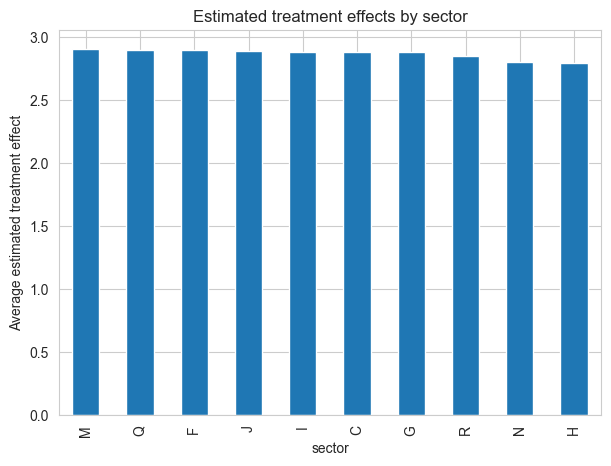

In [15]:

# ==========================================================
# 13. PLOT SECTORAL EFFECTS
# ==========================================================

sector_summary.plot(
    kind="bar"
)

plt.ylabel("Average estimated treatment effect")

plt.title(
    "Estimated treatment effects by sector"
)

plt.show()



# Interpretation

The sectoral analysis helps identify:

- which sectors benefit most from the subsidy,
- and where policy targeting may be more effective.



# 14. Regional heterogeneity

We now analyze treatment effect heterogeneity across regions.


In [16]:

# ==========================================================
# 14. REGIONAL HETEROGENEITY
# ==========================================================

region_results = pd.DataFrame({
    "region": X.loc[X_test.index, "region"],
    "estimated_effect": estimated_effect_test
})

region_summary = (
    region_results
    .groupby("region")["estimated_effect"]
    .mean()
    .sort_values(ascending=False)
)

print(region_summary)


region
Murcia               2.978487
Valencia             2.943950
Castile and Leon     2.937781
Ceuta                2.925627
Aragon               2.906627
La Rioja             2.906117
Canary Islands       2.896412
Melilla              2.895887
Andalusia            2.882040
Madrid               2.878396
Catalonia            2.867443
Castile-La Mancha    2.835051
Asturias             2.827878
Cantabria            2.827536
Galicia              2.824052
Navarre              2.808690
Extremadura          2.802907
Basque Country       2.787948
Balearic Islands     2.774615
Name: estimated_effect, dtype: float64


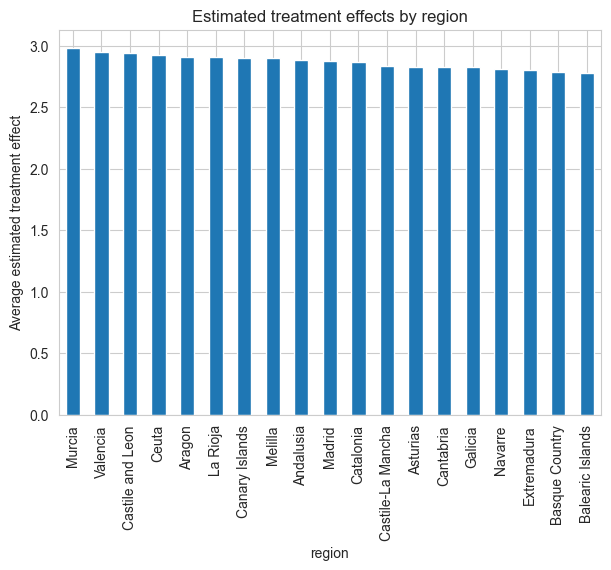

In [17]:

# ==========================================================
# 15. PLOT REGIONAL EFFECTS
# ==========================================================

region_summary.plot(
    kind="bar"
)

plt.ylabel("Average estimated treatment effect")

plt.title(
    "Estimated treatment effects by region"
)

plt.show()



# Interpretation

Regional heterogeneity may reflect:

- different economic structures,
- different digital capabilities,
- or regional differences in policy implementation.



# 16. Propensity score overlap

A key assumption in causal inference is overlap (common support).

Treated and control firms must be sufficiently comparable.


In [18]:

# ==========================================================
# 16. PROPENSITY SCORE MODEL
# ==========================================================

propensity_scores = model_t.fit(
    X_encoded,
    T
).predict_proba(X_encoded)[:,1]

df["propensity_score"] = propensity_scores


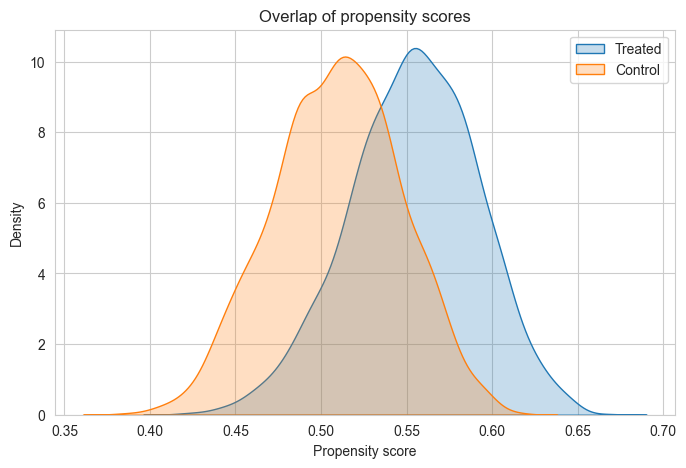

In [19]:

# ==========================================================
# 17. PROPENSITY SCORE OVERLAP
# ==========================================================

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df.loc[df["aid_received"] == 1],
    x="propensity_score",
    fill=True,
    label="Treated"
)

sns.kdeplot(
    data=df.loc[df["aid_received"] == 0],
    x="propensity_score",
    fill=True,
    label="Control"
)

plt.xlabel("Propensity score")

plt.title(
    "Overlap of propensity scores"
)

plt.legend()

plt.show()



# Final conclusions

This notebook illustrated:

- heterogeneous treatment effect estimation,
- causal forests,
- nuisance models,
- overlap diagnostics,
- and heterogeneity analysis by sector and region.

The example highlights an important idea:

## causal machine learning is not only prediction.

Reliable causal estimation requires:

- overlap,
- good nuisance models,
- robust treatment assignment,
- and careful interpretation.



# Export results for explainability analysis

The estimated heterogeneous treatment effects are exported so they can be used in subsequent explainability and interpretability notebooks.


In [20]:

# ==========================================================
# EXPORT RESULTS FOR INTERPRETABLE AI ANALYSIS
# ==========================================================

# Store estimated treatment effects
results_df = df.copy()

# Create full-sample estimated effects
estimated_effect_full = causal_forest.effect(X_encoded)

results_df["estimated_cate"] = estimated_effect_full

# Export dataset with causal forest results
output_path = "../output/simulated_subsidy_dataset_with_causal_forest_results.csv"

results_df.to_csv(
    output_path,
    index=False
)

print(f"Results exported to: {output_path}")


Results exported to: ../output/simulated_subsidy_dataset_with_causal_forest_results.csv
